In [ ]:
# Run this cell first
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# sklearn imports
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, IsolationForest
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.impute import SimpleImputer

import joblib   # to save models

# display settings
pd.set_option('display.max_columns', 50)


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Set the path to your dataset in Drive (update if different)
DATA_PATH = "/content/drive/MyDrive/electricity_bill_dataset.csv"


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df = pd.read_csv(DATA_PATH)
print("Rows,Cols:", df.shape)
df.head()


Rows,Cols: (45345, 12)


,Fan,Refrigerator,AirConditioner,Television,Monitor,MotorPump,Month,City,Company,MonthlyHours,TariffRate,ElectricityBill
0,16,23.0,2.0,6.0,1.0,0,10,Hyderabad,Tata Power Company Ltd.,384,8.4,3225.6
1,19,22.0,2.0,3.0,1.0,0,5,Vadodara,NHPC,488,7.8,3806.4
2,7,20.0,2.0,6.0,7.0,0,7,Shimla,Jyoti Structure,416,7.7,3203.2
3,7,22.0,3.0,21.0,1.0,0,6,Mumbai,Power Grid Corp,475,9.2,4370.0
4,11,23.0,2.0,11.0,1.0,0,2,Mumbai,Ratnagiri Gas and Power Pvt. Ltd. (RGPPL),457,9.2,4204.4


In [ ]:
# Basic checks
print("Missing values per column:\n", df.isna().sum())
print("\nDuplicate rows:", df.duplicated().sum())
print("\nDtypes:\n", df.dtypes)
display(df.describe(include='all').T)


Missing values per column:
 Fan                0
Refrigerator       0
AirConditioner     0
Television         0
Monitor            0
MotorPump          0
Month              0
City               0
Company            0
MonthlyHours       0
TariffRate         0
ElectricityBill    0
dtype: int64

Duplicate rows: 0

Dtypes:
 Fan                  int64
Refrigerator       float64
AirConditioner     float64
Television         float64
Monitor            float64
MotorPump            int64
Month                int64
City                object
Company             object
MonthlyHours         int64
TariffRate         float64
ElectricityBill    float64
dtype: object


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Fan,45345.0,NaN,NaN,NaN,13.990694,5.470816,5.0,9.0,14.0,19.0,23.0
Refrigerator,45345.0,NaN,NaN,NaN,21.705458,1.672575,17.0,22.0,22.0,23.0,23.0
AirConditioner,45345.0,NaN,NaN,NaN,1.503959,1.115482,0.0,1.0,2.0,2.0,3.0
Television,45345.0,NaN,NaN,NaN,12.502635,5.756007,3.0,7.0,13.0,17.0,22.0
Monitor,45345.0,NaN,NaN,NaN,2.865057,3.894933,1.0,1.0,1.0,1.0,12.0
MotorPump,45345.0,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Month,45345.0,NaN,NaN,NaN,6.488058,3.443252,1.0,3.0,6.0,9.0,12.0
City,45345,16,Hyderabad,2914,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Company,45345,32,Ringfeder Power Transmission India Pvt. Ltd.,1486,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MonthlyHours,45345.0,NaN,NaN,NaN,515.083207,122.618017,95.0,429.0,515.0,601.0,926.0


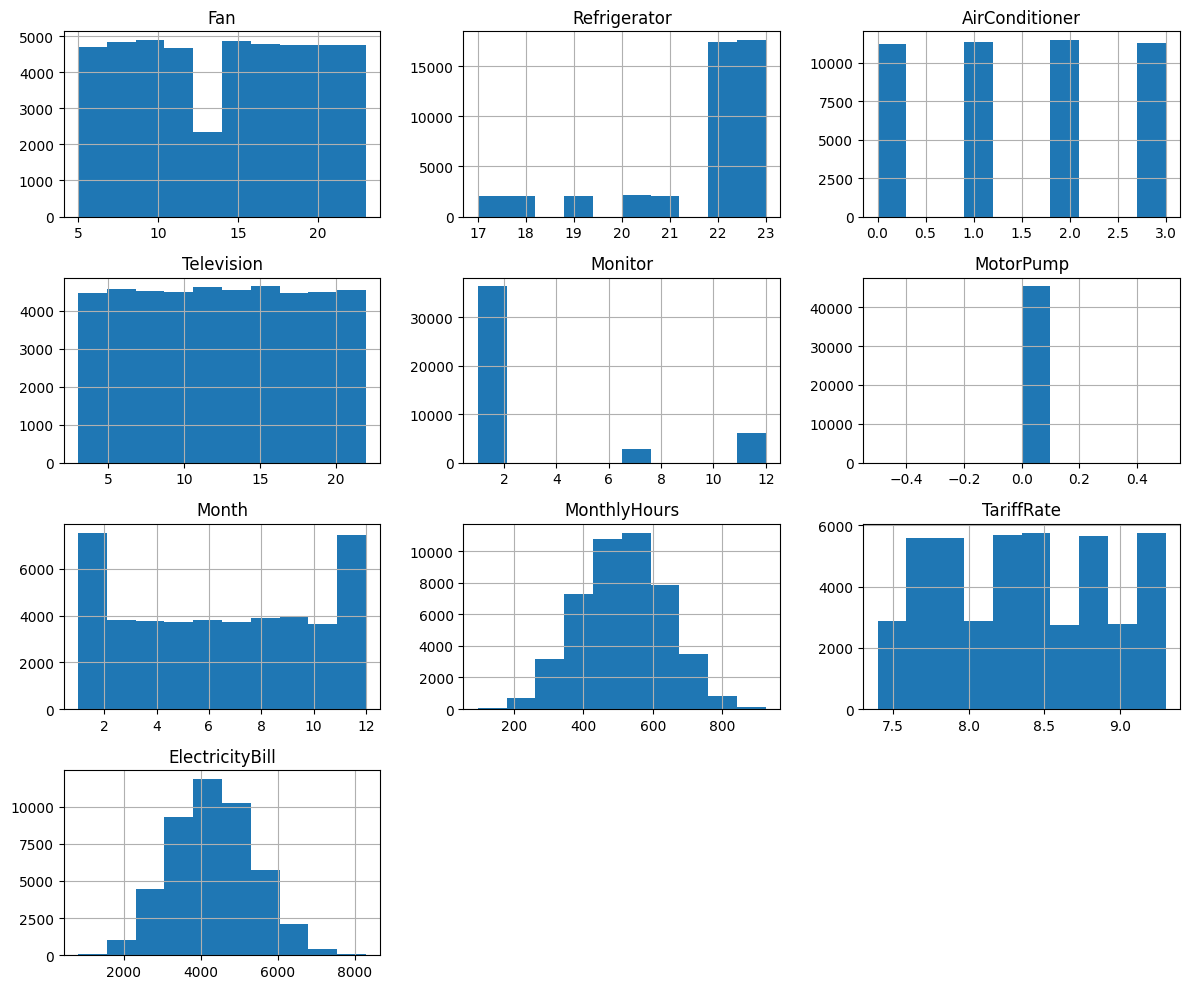

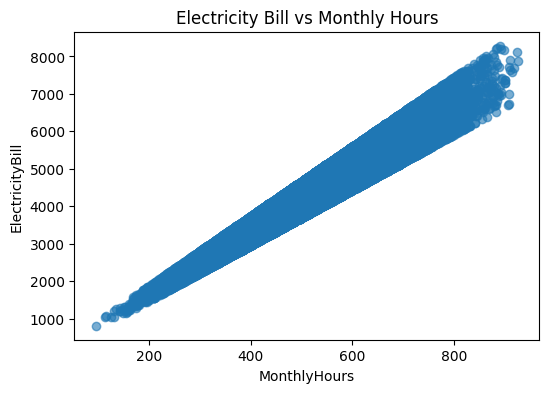

In [ ]:
# Histogram of numerical columns
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
df[num_cols].hist(figsize=(12,10))
plt.tight_layout()
plt.show()

# Scatter: ElectricityBill vs MonthlyHours
plt.figure(figsize=(6,4))
plt.scatter(df['MonthlyHours'], df['ElectricityBill'], alpha=0.6)
plt.xlabel("MonthlyHours")
plt.ylabel("ElectricityBill")
plt.title("Electricity Bill vs Monthly Hours")
plt.show()


In [ ]:
# Example: fraction of MonthlyHours attributed to each appliance (avoid divide by zero)
eps = 1e-6
appliances = ['Fan','Refrigerator','AirConditioner','Television','Monitor','MotorPump']

# make sure columns exist
appliances = [c for c in appliances if c in df.columns]

df['TotalApplianceHours'] = df[appliances].sum(axis=1)
df['TotalApplianceHours'] = df['TotalApplianceHours'].replace(0, eps)  # avoid 0 division

for c in appliances:
    df[c + '_share'] = df[c] / df['TotalApplianceHours']

# Example: AC presence boolean
if 'AirConditioner' in df.columns:
    df['AC_present'] = (df['AirConditioner'] > 0).astype(int)

# view new columns
df[[*appliances, 'TotalApplianceHours', 'AC_present']].head()


,Fan,Refrigerator,AirConditioner,Television,Monitor,MotorPump,TotalApplianceHours,AC_present
0,16,23.0,2.0,6.0,1.0,0,48.0,1
1,19,22.0,2.0,3.0,1.0,0,47.0,1
2,7,20.0,2.0,6.0,7.0,0,42.0,1
3,7,22.0,3.0,21.0,1.0,0,54.0,1
4,11,23.0,2.0,11.0,1.0,0,48.0,1


In [ ]:
# Example: fraction of MonthlyHours attributed to each appliance (avoid divide by zero)
eps = 1e-6
appliances = ['Fan','Refrigerator','AirConditioner','Television','Monitor','MotorPump']

# make sure columns exist
appliances = [c for c in appliances if c in df.columns]

df['TotalApplianceHours'] = df[appliances].sum(axis=1)
df['TotalApplianceHours'] = df['TotalApplianceHours'].replace(0, eps)  # avoid 0 division

for c in appliances:
    df[c + '_share'] = df[c] / df['TotalApplianceHours']

# Example: AC presence boolean
if 'AirConditioner' in df.columns:
    df['AC_present'] = (df['AirConditioner'] > 0).astype(int)

# view new columns
df[[*appliances, 'TotalApplianceHours', 'AC_present']].head()


,Fan,Refrigerator,AirConditioner,Television,Monitor,MotorPump,TotalApplianceHours,AC_present
0,16,23.0,2.0,6.0,1.0,0,48.0,1
1,19,22.0,2.0,3.0,1.0,0,47.0,1
2,7,20.0,2.0,6.0,7.0,0,42.0,1
3,7,22.0,3.0,21.0,1.0,0,54.0,1
4,11,23.0,2.0,11.0,1.0,0,48.0,1


In [ ]:
# TARGET
TARGET = 'ElectricityBill'

# Candidate features (numeric + categorical)
# Numeric base
num_features = ['Fan','Refrigerator','AirConditioner','Television','Monitor','MotorPump','MonthlyHours','TariffRate']
num_features = [c for c in num_features if c in df.columns]

# Some engineered numeric shares (optional)
share_features = [c + '_share' for c in appliances if (c + '_share') in df.columns]
num_features += share_features

# Categorical features
cat_features = [c for c in ['City','Company','Month'] if c in df.columns]

print("Numeric features:", num_features)
print("Categorical features:", cat_features)


Numeric features: ['Fan', 'Refrigerator', 'AirConditioner', 'Television', 'Monitor', 'MotorPump', 'MonthlyHours', 'TariffRate', 'Fan_share', 'Refrigerator_share', 'AirConditioner_share', 'Television_share', 'Monitor_share', 'MotorPump_share']
Categorical features: ['City', 'Company', 'Month']


In [ ]:
# Drop any rows with missing TARGET if present (not expected)
df = df.dropna(subset=[TARGET])

X = df[num_features + cat_features].copy()
y = df[TARGET].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42)

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)


Train shape: (36276, 17) Test shape: (9069, 17)


In [ ]:
# Preprocessing transformers
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())    # good for linear models
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, num_features),
    ('cat', categorical_transformer, cat_features)
])

# Pipeline: Preprocess -> Linear Regression
lr_pipeline = Pipeline(steps=[
    ('preproc', preprocessor),
    ('lr', LinearRegression())
])

# Fit baseline
lr_pipeline.fit(X_train, y_train)
y_pred_lr = lr_pipeline.predict(X_test)

# Metrics
def regression_metrics(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return {'RMSE':rmse, 'MAE':mae, 'R2':r2}

metrics_lr = regression_metrics(y_test, y_pred_lr)
metrics_lr


{'RMSE': np.float64(70.55840303947501),
 'MAE': 49.2724400579395,
 'R2': 0.9956306781901272}

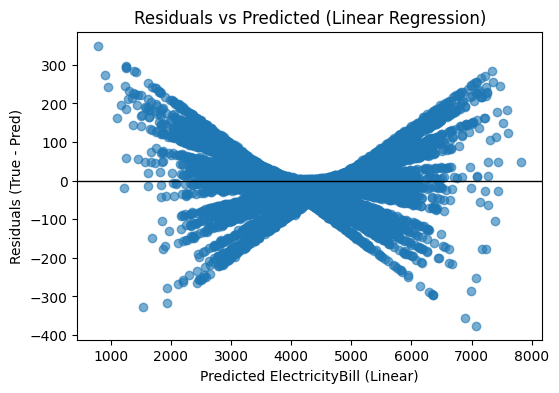

{'RMSE': np.float64(70.55840303947501),
 'MAE': 49.2724400579395,
 'R2': 0.9956306781901272}

In [ ]:
# Residuals
residuals = y_test - y_pred_lr

plt.figure(figsize=(6,4))
plt.scatter(y_pred_lr, residuals, alpha=0.6)
plt.axhline(0, color='black', linewidth=1)
plt.xlabel("Predicted ElectricityBill (Linear)")
plt.ylabel("Residuals (True - Pred)")
plt.title("Residuals vs Predicted (Linear Regression)")
plt.show()

metrics_lr


In [ ]:
# For tree-based models, scaling not necessary, but we keep imputer for numeric
numeric_transformer_rf = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

preprocessor_rf = ColumnTransformer(transformers=[
    ('num', numeric_transformer_rf, num_features),
    ('cat', categorical_transformer, cat_features)
])

rf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)

rf_pipeline = Pipeline(steps=[
    ('preproc', preprocessor_rf),
    ('rf', rf)
])

# Fit Random Forest
rf_pipeline.fit(X_train, y_train)
y_pred_rf = rf_pipeline.predict(X_test)

metrics_rf = regression_metrics(y_test, y_pred_rf)
metrics_rf


{'RMSE': np.float64(5.6669527036584375),
 'MAE': 1.521181773073668,
 'R2': 0.9999718151503056}

In [ ]:
print("Linear Regression metrics:", metrics_lr)
print("Random Forest metrics     :", metrics_rf)


Linear Regression metrics: {'RMSE': np.float64(70.55840303947501), 'MAE': 49.2724400579395, 'R2': 0.9956306781901272}
Random Forest metrics     : {'RMSE': np.float64(5.6669527036584375), 'MAE': 1.521181773073668, 'R2': 0.9999718151503056}


In [ ]:
# Get preprocessed feature names (onehot creates many)
# Helper to get column names after ColumnTransformer + OneHotEncoder
def get_feature_names(column_transformer):
    # column_transformer is preprocessor_rf
    feature_names = []
    # numeric features:
    feature_names.extend(num_features)
    # categorical pipeline
    cat_pipe = column_transformer.named_transformers_['cat']
    ohe = cat_pipe.named_steps['onehot']
    ohe_cols = ohe.get_feature_names_out(cat_features).tolist()
    feature_names.extend(ohe_cols)
    return feature_names

feat_names = get_feature_names(preprocessor_rf)
# extract feature importances from trained rf
importances = rf_pipeline.named_steps['rf'].feature_importances_

# Put into DataFrame
fi = pd.DataFrame({'feature': feat_names, 'importance': importances})
fi = fi.sort_values('importance', ascending=False).reset_index(drop=True)
fi.head(20)


,feature,importance
0,MonthlyHours,0.920835
1,TariffRate,0.077912
2,City_Ratnagiri,0.000250
3,City_New Delhi,0.000229
4,City_Nagpur,0.000146
5,City_Ahmedabad,0.000102
6,City_Dahej,0.000066
7,City_Pune,0.000066
8,City_Kolkata,0.000063
9,City_Navi Mumbai,0.000054


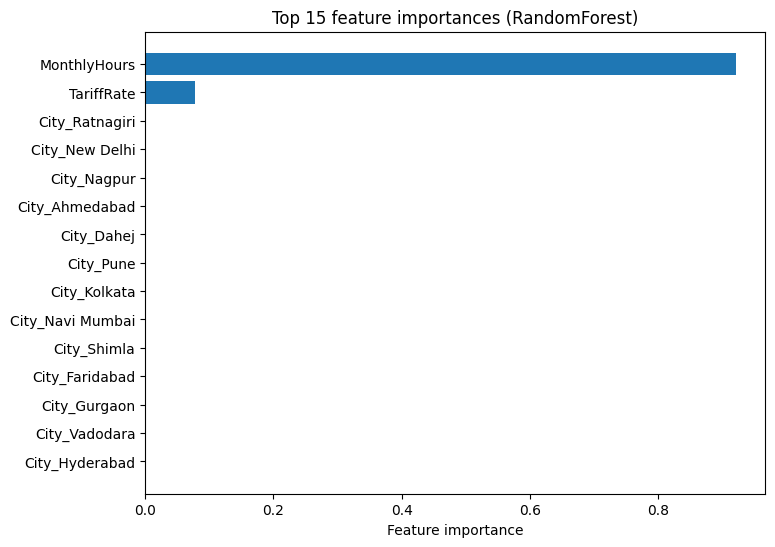

In [ ]:
plt.figure(figsize=(8,6))
plt.barh(fi['feature'][:15][::-1], fi['importance'][:15][::-1])
plt.xlabel("Feature importance")
plt.title("Top 15 feature importances (RandomForest)")
plt.show()


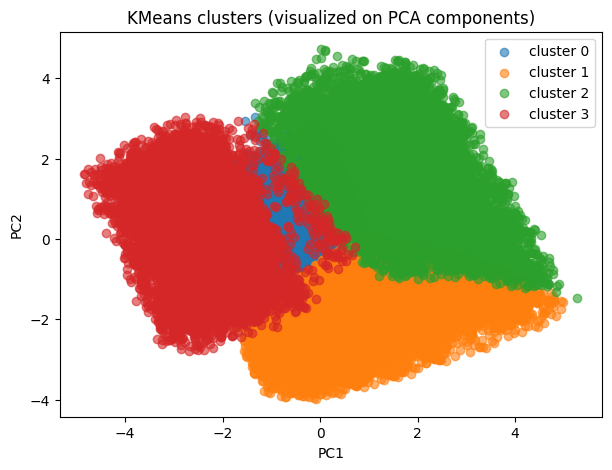

,Fan,Refrigerator,AirConditioner,Television,Monitor,MotorPump,MonthlyHours,TariffRate,Fan_share,Refrigerator_share,AirConditioner_share,Television_share,Monitor_share,MotorPump_share,ElectricityBill
cluster,,,,,,,,,,,,,,,
0,17.27,22.51,1.53,16.56,1.00,0.0,577.77,8.38,0.29,0.38,0.03,0.28,0.02,0.0,4839.74
1,14.72,22.18,1.46,6.44,1.12,0.0,447.29,8.36,0.31,0.49,0.03,0.14,0.02,0.0,3741.91
2,7.39,19.69,1.53,14.16,2.25,0.0,449.67,8.37,0.17,0.44,0.03,0.31,0.05,0.0,3761.04
3,16.79,22.51,1.49,12.47,11.85,0.0,625.63,8.37,0.26,0.35,0.02,0.19,0.18,0.0,5240.21


In [ ]:
# Prepare only numeric features (and monthlyhours etc.) for clustering
cluster_features = num_features.copy()  # you can tweak this list

# Preprocess numeric with median imputer + standard scaler
scaler = StandardScaler()
X_cluster = df[cluster_features].copy()
X_cluster = SimpleImputer(strategy='median').fit_transform(X_cluster)
X_cluster_scaled = scaler.fit_transform(X_cluster)

# PCA to 2D for visualization
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_cluster_scaled)

# KMeans (choose k=3 or k=4)
k = 4
kmeans = KMeans(n_clusters=k, random_state=42)
clusters = kmeans.fit_predict(X_cluster_scaled)

# Add to df for inspection
df['cluster'] = clusters
df['pca1'] = X_pca[:,0]
df['pca2'] = X_pca[:,1]

plt.figure(figsize=(7,5))
for ci in range(k):
    idx = df['cluster'] == ci
    plt.scatter(df.loc[idx,'pca1'], df.loc[idx,'pca2'], label=f'cluster {ci}', alpha=0.6)
plt.legend()
plt.title("KMeans clusters (visualized on PCA components)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

# Quick cluster summary
df.groupby('cluster')[cluster_features + ['ElectricityBill']].mean().round(2)


In [ ]:
iso = IsolationForest(contamination=0.01, random_state=42)
iso.fit(X_cluster_scaled)
anomaly_flags = iso.predict(X_cluster_scaled)  # -1 is anomaly, 1 is normal

df['anomaly'] = (anomaly_flags == -1).astype(int)
print("Anomalies found:", df['anomaly'].sum())
df[df['anomaly'] == 1].head()


Anomalies found: 454


,Fan,Refrigerator,AirConditioner,Television,Monitor,MotorPump,Month,City,Company,MonthlyHours,TariffRate,ElectricityBill,TotalApplianceHours,Fan_share,Refrigerator_share,AirConditioner_share,Television_share,Monitor_share,MotorPump_share,AC_present,cluster,pca1,pca2,anomaly
136,7,18.0,0.0,21.0,7.0,0,12,New Delhi,Sterlite Power Transmission Ltd,476,8.5,4046.0,53.0,0.132075,0.339623,0.000000,0.396226,0.132075,0.0,0,2,0.256204,3.671218,1
279,9,17.0,3.0,5.0,7.0,0,9,New Delhi,NHPC,383,8.5,3255.5,41.0,0.219512,0.414634,0.073171,0.121951,0.170732,0.0,1,2,1.509760,-0.054868,1
341,8,17.0,3.0,3.0,1.0,0,5,Chennai,NHPC,376,8.8,3308.8,32.0,0.250000,0.531250,0.093750,0.093750,0.031250,0.0,1,1,3.465012,-1.196230,1
631,5,17.0,0.0,21.0,7.0,0,12,Faridabad,Orient Green,503,8.1,4074.3,50.0,0.100000,0.340000,0.000000,0.420000,0.140000,0.0,0,2,0.604332,4.266990,1
701,5,18.0,3.0,3.0,1.0,0,4,Shimla,Toshiba Transmission & Distribution Systems (I...,309,7.7,2379.3,30.0,0.166667,0.600000,0.100000,0.100000,0.033333,0.0,1,2,4.526537,-1.010655,1


In [ ]:
# Save the best RF pipeline (or rf_pipeline if not tuned)
model_to_save = rf_pipeline  # or best_model if you ran GridSearch
OUT_DIR = "/content/drive/MyDrive/ML Projects/EnergyConsumption/models"
os.makedirs(OUT_DIR, exist_ok=True)
joblib.dump(model_to_save, os.path.join(OUT_DIR, "rf_pipeline_v1.joblib"))
print("Saved model to", OUT_DIR)


Saved model to /content/drive/MyDrive/ML Projects/EnergyConsumption/models


In [ ]:
# Save predictions alongside test X
test_out = X_test.copy()
test_out['y_true'] = y_test
test_out['y_pred_rf'] = y_pred_rf
out_path = "/content/drive/MyDrive/ML Projects/EnergyConsumption/test_predictions.csv"
test_out.to_csv(out_path, index=False)
print("Saved test predictions to:", out_path)


Saved test predictions to: /content/drive/MyDrive/ML Projects/EnergyConsumption/test_predictions.csv
